# Reproducing and Extending a Stacking Ensemble for Heart Disease Classification

## Reproduction of the Published Methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, xgboost
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

### Data Preparation

In [2]:
FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
CONTINUOUS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
DISCRETE = [c for c in FEATURES if c not in CONTINUOUS]
print(f'scikit-learn: {sklearn.__version__}')
print(f'XGBoost: {xgboost.__version__}')

scikit-learn: 1.8.0
XGBoost: 3.4.1


In [3]:
data = pd.read_csv('heart.csv')

In [4]:
assert set(data.columns) == set(FEATURES + ['target'])
assert set(data.target.unique()) == {0, 1}

In [5]:
X = data[FEATURES].copy()
y = data.target.copy()

In [6]:
print(f'Shape: {data.shape}')
print(f'Target counts: {y.value_counts().sort_index().to_dict()}')
print(f'Missing cells: {int(data.isna().sum().sum())}')
print(f'Exact duplicate rows: {int(data.duplicated().sum())}')

Shape: (1025, 14)
Target counts: {0: 499, 1: 526}
Missing cells: 0
Exact duplicate rows: 723


In [7]:
assert not data.isna().any().any(), 'This notebook expects the supplied complete CSV'
assert not data.groupby(FEATURES).target.nunique().gt(1).any(), 'Conflicting labels in repeated profiles'
display(X.describe().round(2).T)

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.43,9.07,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.70,0.46,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.94,1.03,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.61,17.52,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.00,51.59,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.11,23.01,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.07,1.18,0.0,0.0,0.8,1.8,6.2


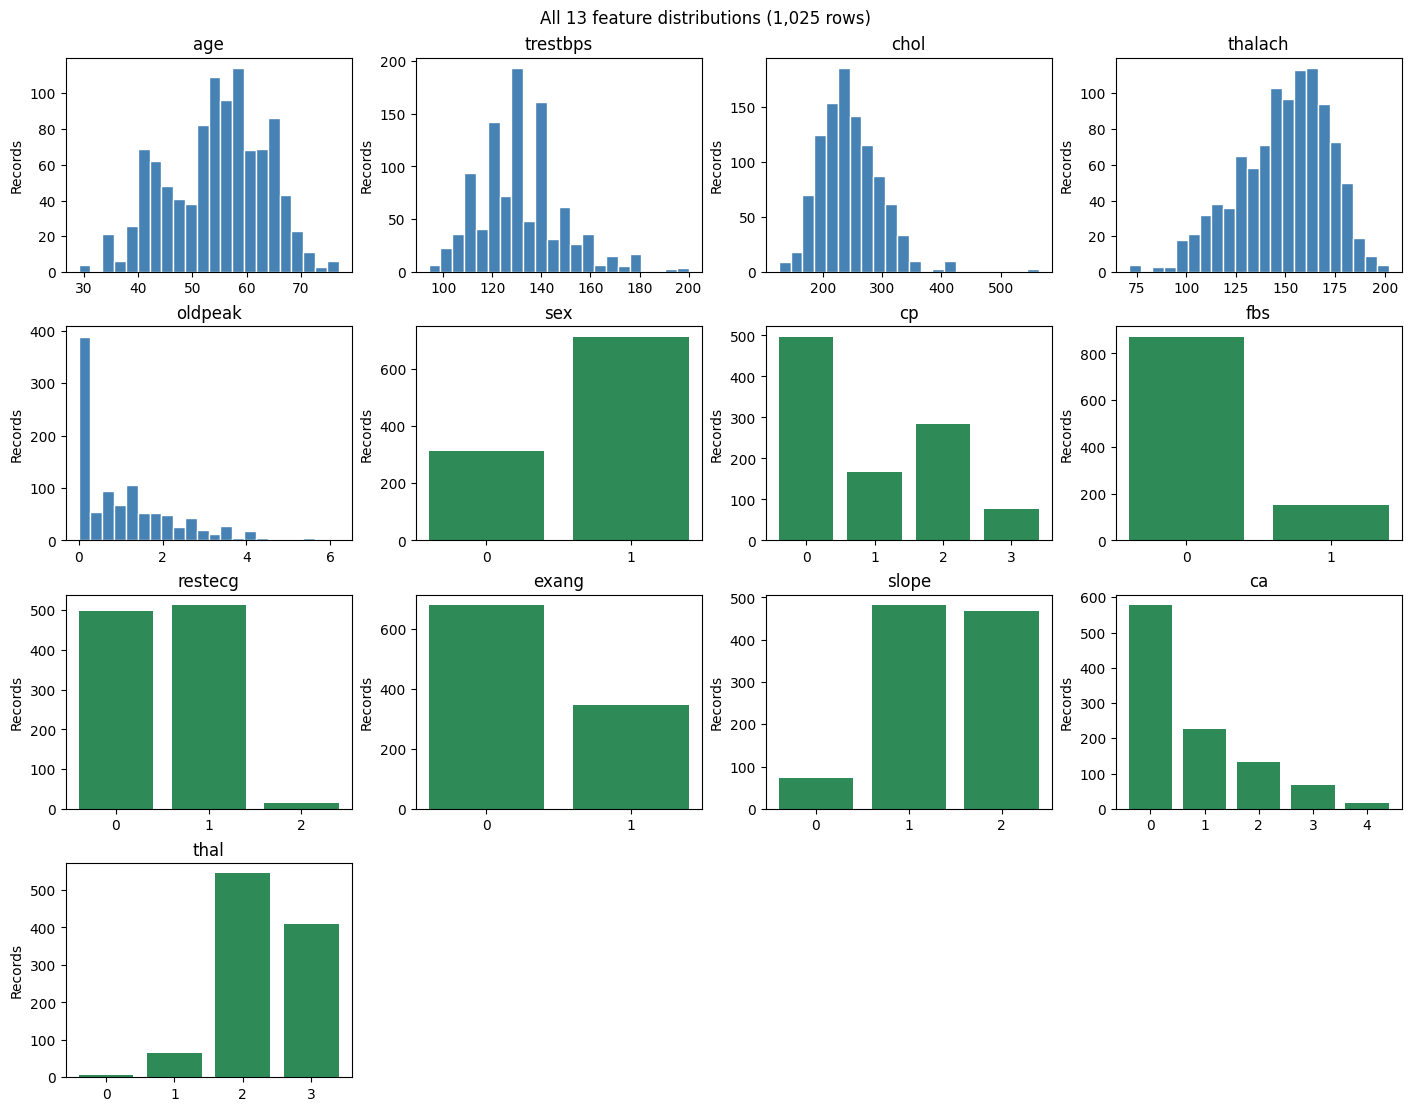

In [8]:
fig, axes = plt.subplots(4, 4, figsize = (14, 11), layout = 'constrained')
for ax, column in zip(axes.flat, CONTINUOUS + DISCRETE):
    if column in CONTINUOUS:
        ax.hist(X[column], bins = 22, color = 'steelblue', edgecolor = 'white')
    else:
        counts = X[column].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color = 'seagreen')
    ax.set(title = column, ylabel = 'Records')
for ax in list(axes.flat)[len(FEATURES):]: ax.axis('off')
fig.suptitle('All 13 feature distributions (1,025 rows)')
plt.show()

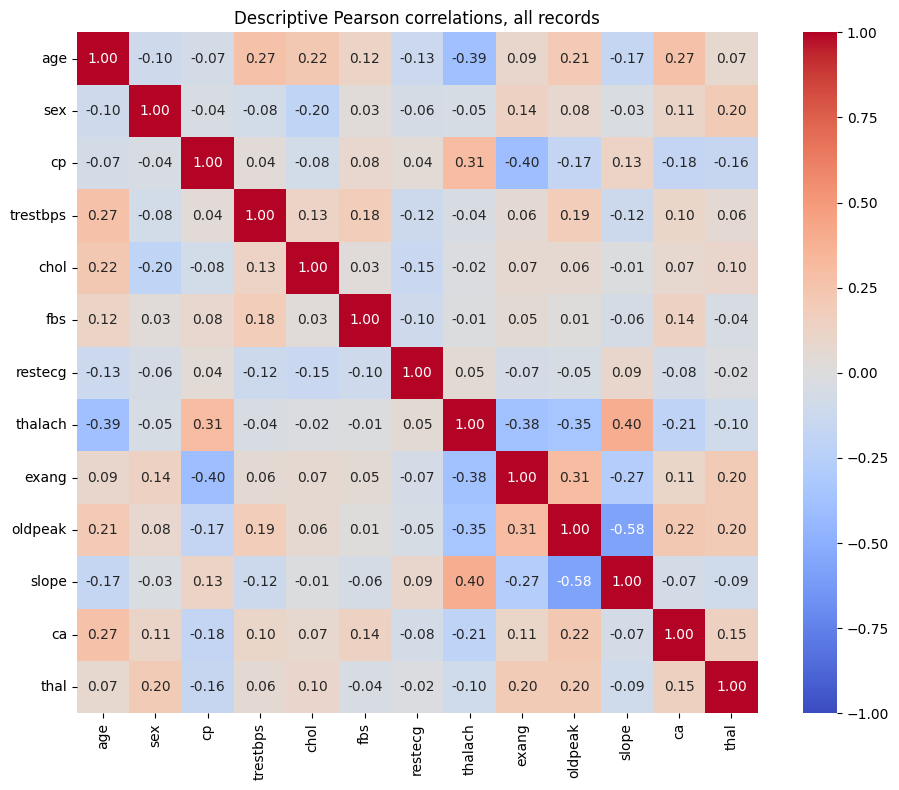

In [9]:
plt.figure(figsize = (10, 8))
sns.heatmap(
    X.corr(),
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    vmin = -1,
    vmax = 1,
    square = True)
plt.title('Descriptive Pearson correlations, all records')
plt.tight_layout()
plt.show()

In [10]:
SEED = 42

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = SEED
)

In [12]:
def scaled(train, other):
    train, other = train.copy(), other.copy()
    train[CONTINUOUS] = train[CONTINUOUS].astype(float)
    other[CONTINUOUS] = other[CONTINUOUS].astype(float)
    scaler = StandardScaler()
    train.loc[:, CONTINUOUS] = scaler.fit_transform(train[CONTINUOUS])
    other.loc[:, CONTINUOUS] = scaler.transform(other[CONTINUOUS])
    return train, other

In [13]:
Xtr_scaled, Xte_scaled = scaled(X_train, X_test)

overlap = len(X_test.merge(X_train.drop_duplicates(), on = FEATURES, how = 'inner'))

print(f"Train/test rows: {len(X_train)} / {len(X_test)}")
print(f"Test records matching a training record: {overlap} / {len(X_test)}")

Train/test rows: 820 / 205
Test records matching a training record: 202 / 205


### Six Individual Classifiers

In [14]:
def base_models():
    return {
        'LR': LogisticRegression(max_iter = 1000, random_state = SEED),
        'NB': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors = 5),
        'DT': DecisionTreeClassifier(random_state = SEED),
        'RF': RandomForestClassifier(n_estimators = 100, random_state = SEED),
        'XGB': XGBClassifier(eval_metric = 'logloss', random_state = SEED, n_jobs = 2),
    }

In [15]:
def evaluate(actual, probability):
    pred = (probability >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, pred, labels = [0, 1]).ravel()
    return dict(
        accuracy = accuracy_score(actual, pred),
        precision = precision_score(actual, pred, zero_division = 0),
        recall = recall_score(actual,pred,zero_division = 0),
        f1 = f1_score(actual, pred, zero_division = 0),
        auc = roc_auc_score(actual, probability),
        tn = int(tn),
        fp = int(fp),
        fn = int(fn),
        tp = int(tp)
    )

In [16]:
fitted = {}
probabilities = {}
part1 = {}

for name, estimator in base_models().items():
    fitted[name] = clone(estimator).fit(Xtr_scaled, y_train)
    probabilities[name] = fitted[name].predict_proba(Xte_scaled)[:, 1]
    part1[name] = evaluate(y_test, probabilities[name])

display(pd.DataFrame(part1).T.round(4))

,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
LR,0.8146,0.7638,0.9238,0.8362,0.9297,70.0,30.0,8.0,97.0
NB,0.8293,0.8070,0.8762,0.8402,0.9043,78.0,22.0,13.0,92.0
KNN,0.8537,0.8571,0.8571,0.8571,0.9540,85.0,15.0,15.0,90.0
DT,0.9854,1.0000,0.9714,0.9855,0.9857,100.0,0.0,3.0,102.0
RF,1.0000,1.0000,1.0000,1.0000,1.0000,100.0,0.0,0.0,105.0
XGB,1.0000,1.0000,1.0000,1.0000,1.0000,100.0,0.0,0.0,105.0


### Training the Stacking Model

In [17]:
def fit_stack(train_X, train_y, test_X, fold_seed = SEED, group_aware = False):
    estimators = base_models()
    if group_aware:
        cv = StratifiedGroupKFold(n_splits = 5, shuffle = True, random_state = fold_seed)
        groups = pd.util.hash_pandas_object(train_X[FEATURES], index = False).to_numpy()
        folds = cv.split(train_X, train_y, groups)
    else:
        cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = fold_seed)
        folds = cv.split(train_X, train_y)
    oof = np.empty((len(train_X), len(estimators)))
    for fit_idx, valid_idx in folds:
        if group_aware:
            assert set(groups[fit_idx]).isdisjoint(groups[valid_idx])
        A, B = scaled(train_X.iloc[fit_idx], train_X.iloc[valid_idx])
        for j, estimator in enumerate(estimators.values()):
            m = clone(estimator).fit(A, train_y.iloc[fit_idx])
            oof[valid_idx, j] = m.predict_proba(B)[:, 1]
    meta = LogisticRegression(max_iter = 1000, random_state = fold_seed).fit(oof, train_y)
    A, B = scaled(train_X, test_X)
    meta_test = np.column_stack([
        clone(estimator).fit(A, train_y).predict_proba(B)[:, 1]
        for estimator in estimators.values()])
    return meta.predict_proba(meta_test)[:, 1], oof

In [18]:
probabilities['Stack'], oof = fit_stack(X_train, y_train, X_test)
part1['Stack'] = evaluate(y_test, probabilities['Stack'])

print(f'Out-of-fold meta-feature shape: {oof.shape}')
display(pd.DataFrame(part1).T.round(4))

Out-of-fold meta-feature shape: (820, 6)


,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
LR,0.8146,0.7638,0.9238,0.8362,0.9297,70.0,30.0,8.0,97.0
NB,0.8293,0.8070,0.8762,0.8402,0.9043,78.0,22.0,13.0,92.0
KNN,0.8537,0.8571,0.8571,0.8571,0.9540,85.0,15.0,15.0,90.0
DT,0.9854,1.0000,0.9714,0.9855,0.9857,100.0,0.0,3.0,102.0
RF,1.0000,1.0000,1.0000,1.0000,1.0000,100.0,0.0,0.0,105.0
XGB,1.0000,1.0000,1.0000,1.0000,1.0000,100.0,0.0,0.0,105.0
Stack,1.0000,1.0000,1.0000,1.0000,1.0000,100.0,0.0,0.0,105.0


In [19]:
rows = []

for name, result in part1.items():
    tn = result["tn"]
    fp = result["fp"]
    fn = result["fn"]
    tp = result["tp"]

    actual = [0] * (tn + fp) + [1] * (fn + tp)
    predicted = [0] * tn + [1] * fp + [0] * fn + [1] * tp

    rows.append({
        "Model": name,
        "Accuracy": result["accuracy"],
        "F1 Score": result["f1"],
        "Recall": result["recall"],
        "Precision": result["precision"],
        "Sensitivity": result["recall"],
        "Specificity": tn / (tn + fp) if (tn + fp) else 0,
        "MCC": matthews_corrcoef(actual, predicted),
        "AUC": result["auc"],
    })

reproduced_table = pd.DataFrame(rows).set_index("Model")
display(reproduced_table.round(4))

,Accuracy,F1 Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
Model,,,,,,,,
LR,0.8146,0.8362,0.9238,0.7638,0.9238,0.70,0.6422,0.9297
NB,0.8293,0.8402,0.8762,0.8070,0.8762,0.78,0.6602,0.9043
KNN,0.8537,0.8571,0.8571,0.8571,0.8571,0.85,0.7071,0.9540
DT,0.9854,0.9855,0.9714,1.0000,0.9714,1.00,0.9712,0.9857
RF,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
XGB,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
Stack,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000


In [20]:
reproduced = pd.DataFrame(part1).T[
    ["accuracy", "f1", "recall", "precision", "auc"]
]

paper = pd.DataFrame({
    "accuracy":  [0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853],
    "f1":        [0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861],
    "recall":    [0.9090, 0.9000, 0.8727, 0.8909, 0.9545, 0.9090, 0.9727],
    "precision": [0.8196, 0.8250, 0.8648, 0.9702, 0.9130, 0.9174, 1.0000],
    "auc":       [0.9204, 0.9185, 0.9304, 0.9702, 0.9734, 0.9830, 0.9880],
}, index = ["LR", "NB", "KNN", "DT", "RF", "XGB", "Stack"])

reproduced = reproduced.loc[paper.index]

comparison = pd.concat(
    {"Reproduced": reproduced, "Paper (Table 11)": paper},
    axis = 1
)

comparison["reproduced - paper"] = (
    reproduced["accuracy"] - paper["accuracy"]
)

display(comparison.round(4))

Reproduced                                   Paper (Table 11)          \
        accuracy      f1  recall precision     auc         accuracy      f1   
LR        0.8146  0.8362  0.9238    0.7638  0.9297           0.8439  0.8620   
NB        0.8293  0.8402  0.8762    0.8070  0.9043           0.8439  0.8608   
KNN       0.8537  0.8571  0.8571    0.8571  0.9540           0.8585  0.8687   
DT        0.9854  0.9855  0.9714    1.0000  0.9857           0.9268  0.9289   
RF        1.0000  1.0000  1.0000    1.0000  1.0000           0.9268  0.9333   
XGB       1.0000  1.0000  1.0000    1.0000  1.0000           0.9073  0.9132   
Stack     1.0000  1.0000  1.0000    1.0000  1.0000           0.9853  0.9861   

                                reproduced - paper  
       recall precision     auc                     
LR     0.9090    0.8196  0.9204            -0.0293  
NB     0.9000    0.8250  0.9185            -0.0146  
KNN    0.8727    0.8648  0.9304            -0.0048  
DT     0.8909    0.9702  0.9702             0.0586  
RF     0.9545    0.9130  0.9734             0.0732  
XGB    0.9090    0.9174  0.9830             0.0927  
Stack  0.9727    1.0000  0.9880             0.0147

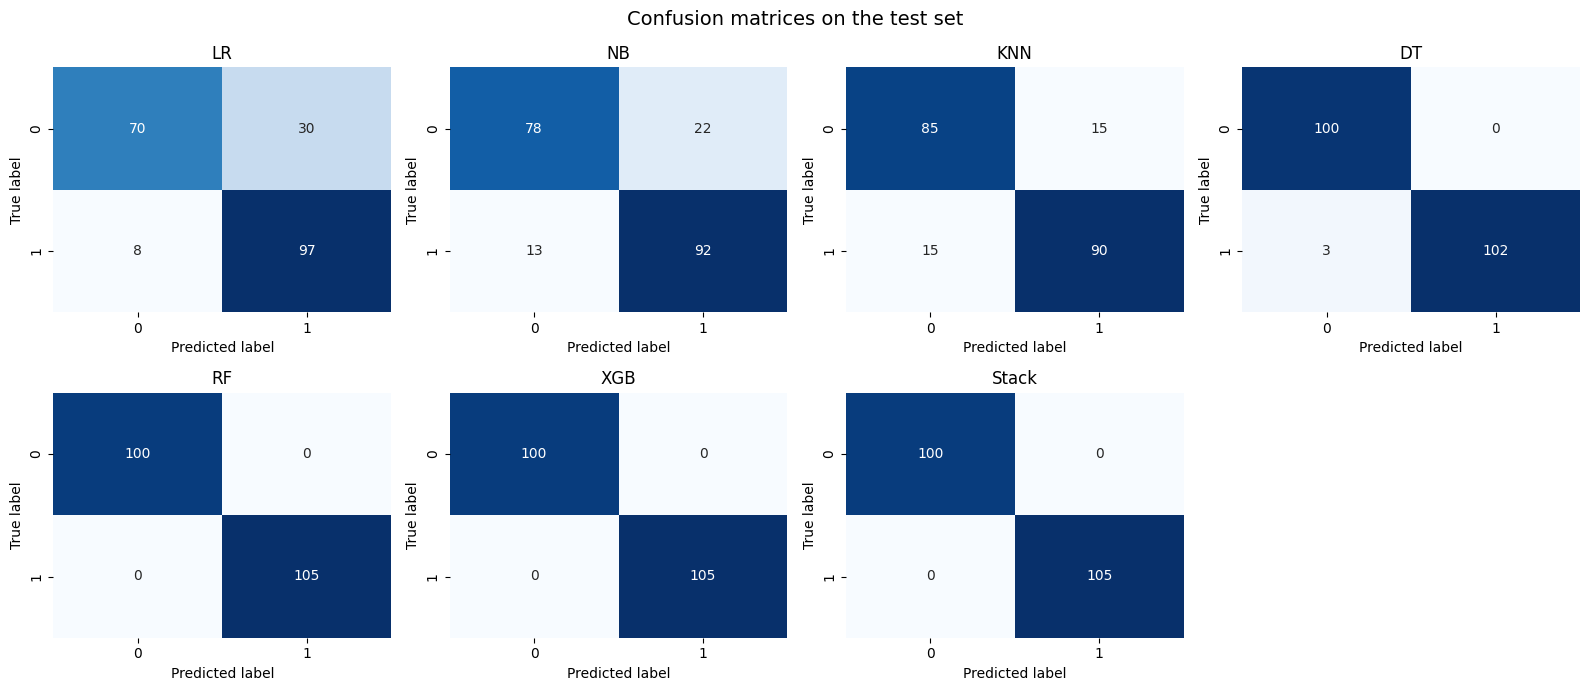

In [21]:
model_order = ["LR", "NB", "KNN", "DT", "RF", "XGB", "Stack"]

fig, axes = plt.subplots(2, 4, figsize = (16, 7))

for ax, name in zip(axes.ravel(), model_order):
    result = part1[name]

    cm = np.array([
        [result["tn"], result["fp"]],
        [result["fn"], result["tp"]]
    ])

    sns.heatmap(
        cm,
        annot = True,
        fmt = "d",
        cmap = "Blues",
        cbar = False,
        xticklabels = ["0", "1"],
        yticklabels = ["0", "1"],
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

axes.ravel()[-1].axis("off")  # Seven models, so hide the eighth panel
fig.suptitle("Confusion matrices on the test set", fontsize = 14)
plt.tight_layout()
plt.show()

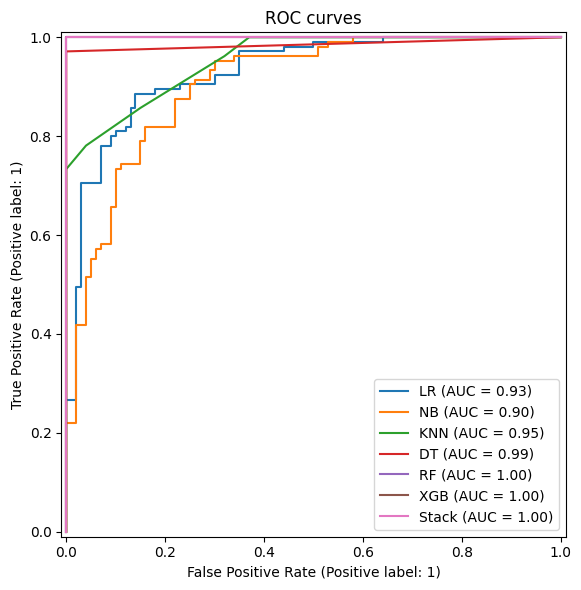

In [22]:
fig, ax = plt.subplots(figsize = (7, 6))

for name in ["LR", "NB", "KNN", "DT", "RF", "XGB", "Stack"]:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name = name,
        ax = ax
    )

ax.set_title("ROC curves")
plt.tight_layout()
plt.show()

## Proposed Evaluation and Decision Method

In [23]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import RepeatedStratifiedKFold

### Keeping Unique Profiles

In [24]:
assert not data.groupby(FEATURES).target.nunique().gt(1).any()
unique_data = data.drop_duplicates(subset = FEATURES).reset_index(drop = True)
X_unique = unique_data[FEATURES].copy()
y_unique = unique_data['target'].copy()
assert not X_unique.duplicated(subset = FEATURES).any()
print(f'Original rows: {len(data)}; unique feature profiles: {len(X_unique)}')
print('Unique-profile class counts:', y_unique.value_counts().sort_index().to_dict())

Original rows: 1025; unique feature profiles: 302
Unique-profile class counts: {0: 138, 1: 164}


### Required Methods

In [25]:
def select_features(train_X, train_y, k = 8, seed = SEED):
    discrete = [feature in DISCRETE for feature in FEATURES]
    scores = mutual_info_classif(
        train_X[FEATURES], train_y,
        discrete_features = discrete,
        random_state = seed
    )
    order = sorted(range(len(FEATURES)), key = lambda j: (-scores[j], j))
    return [FEATURES[j] for j in order[:k]]

In [26]:
def scaled_selected(train_X, test_X, selected):
    A, B = train_X[selected].copy(), test_X[selected].copy()
    continuous = [feature for feature in selected if feature in CONTINUOUS]
    if continuous:
        A[continuous] = A[continuous].astype(float)
        B[continuous] = B[continuous].astype(float)
        scaler = StandardScaler()
        A.loc[:, continuous] = scaler.fit_transform(A[continuous])
        B.loc[:, continuous] = scaler.transform(B[continuous])
    return A, B

In [27]:
def logit(probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return np.log(probability / (1 - probability)).reshape(-1, 1)

In [28]:
def evaluate_part2(actual, probability, threshold, cost_ratio):
    actual, probability = np.asarray(actual), np.asarray(probability)
    pred = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0, 1]).ravel()
    n = len(actual)
    return dict(
        accuracy = accuracy_score(actual, pred),
        precision = precision_score(actual, pred, zero_division = 0),
        recall = recall_score(actual, pred, zero_division = 0),
        f1 = f1_score(actual, pred, zero_division = 0),
        auc = roc_auc_score(actual, probability),
        brier = brier_score_loss(actual, probability),
        specificity = tn / (tn + fp),
        cost_per_record = (fp + cost_ratio * fn) / n,
        net_benefit = (tp / n) - fp / (n * cost_ratio),
        tn = int(tn),
        fp = int(fp),
        fn = int(fn),
        tp = int(tp)
    )

In [29]:
def fit_selected_stack(train_X, train_y, test_X, fold_seed = SEED, k = 8):
    estimators = base_models()
    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = fold_seed)
    oof = np.empty((len(train_X), len(estimators)))
    for fit_idx, valid_idx in cv.split(train_X, train_y):
        fold_X_train, fold_y_train = train_X.iloc[fit_idx], train_y.iloc[fit_idx]
        fold_X_valid = train_X.iloc[valid_idx]
        selected = select_features(fold_X_train, fold_y_train, k = k, seed = fold_seed)
        A, B = scaled_selected(fold_X_train, fold_X_valid, selected)
        for j, estimator in enumerate(estimators.values()):
            model = clone(estimator).fit(A, fold_y_train)
            oof[valid_idx, j] = model.predict_proba(B)[:, 1]

    meta = LogisticRegression(max_iter = 1000, random_state = fold_seed).fit(oof, train_y)
    selected = select_features(train_X, train_y, k = k, seed = fold_seed)
    A, B = scaled_selected(train_X, test_X, selected)
    meta_test = np.column_stack([
        clone(estimator).fit(A, train_y).predict_proba(B)[:, 1]
        for estimator in estimators.values()
    ])
    return meta.predict_proba(meta_test)[:, 1], selected, oof

### Feature Selection

In [30]:
K_CANDIDATES = [7, 8, 9, 10, 11, 13]
INNER_SELECTION_FOLDS = 3

def choose_feature_count(X_fit_part2, y_fit_part2, split_number):
    """Choose k using recall from fitting-data validation folds only."""
    fold_results = []

    k_cv = StratifiedKFold(
        n_splits = INNER_SELECTION_FOLDS,
        shuffle = True,
        random_state = 2000 + split_number
    )
    validation_folds = list(k_cv.split(X_fit_part2, y_fit_part2))
    mean_recall_by_k = {}

    for k in K_CANDIDATES:
        fold_recalls = []

        for inner_train_idx, inner_valid_idx in validation_folds:
            X_inner_train = X_fit_part2.iloc[inner_train_idx].copy()
            y_inner_train = y_fit_part2.iloc[inner_train_idx].copy()
            X_inner_valid = X_fit_part2.iloc[inner_valid_idx].copy()
            y_inner_valid = y_fit_part2.iloc[inner_valid_idx].copy()

            inner_probability, _, _ = fit_selected_stack(
                X_inner_train,
                y_inner_train,
                X_inner_valid,
                fold_seed = SEED + split_number,
                k = k
            )

            inner_prediction = (inner_probability >= 0.5).astype(int)

            fold_recalls.append(
                recall_score(
                    y_inner_valid,
                    inner_prediction,
                    zero_division = 0
                )
            )

        mean_recall_by_k[k] = float(np.mean(fold_recalls))

        fold_results.append(dict(
            split = split_number,
            k = k,
            mean_inner_recall = mean_recall_by_k[k],
            std_inner_recall = float(np.std(fold_recalls, ddof=1))
        ))

    chosen_k = max(
        K_CANDIDATES,
        key = lambda k: (mean_recall_by_k[k], -k)
    )

    return chosen_k, fold_results

In [31]:
cv_part2 = RepeatedStratifiedKFold(
    n_splits = 5,
    n_repeats = 2,
    random_state = SEED
)
outer_splits = list(cv_part2.split(X_unique, y_unique))

tuning_rows = []
chosen_k_rows = []

for split_number, (train_idx, test_idx) in enumerate(
    outer_splits, start = 1
):
    X_train_part2 = X_unique.iloc[train_idx].copy()
    y_train_part2 = y_unique.iloc[train_idx].copy()

    chosen_k, fold_results = choose_feature_count(
        X_train_part2,
        y_train_part2,
        split_number
    )

    tuning_rows.extend(fold_results)
    chosen_k_rows.append({
        "split": split_number,
        "chosen_k": chosen_k
    })

tuning_results = pd.DataFrame(tuning_rows)
chosen_k_results = pd.DataFrame(chosen_k_rows)

print("Training-only mean validation recall:")
display(
    tuning_results.pivot(
        index = "split",
        columns = "k",
        values = "mean_inner_recall"
    ).round(4)
)

print("Chosen k for each round:")
display(chosen_k_results)

Training-only mean validation recall:


k,7,8,9,10,11,13
split,,,,,,
1,0.8314,0.8473,0.8395,0.8395,0.8321,0.8397
2,0.8857,0.8702,0.8703,0.8857,0.8626,0.8622
3,0.8636,0.8864,0.8561,0.8636,0.8485,0.8788
4,0.8554,0.8788,0.8786,0.8939,0.8786,0.8788
5,0.8705,0.8705,0.8857,0.9010,0.8705,0.8703
6,0.8402,0.8559,0.8629,0.8555,0.8631,0.8629
7,0.8703,0.8552,0.8554,0.8705,0.8554,0.8476
8,0.9015,0.8788,0.9091,0.9091,0.9091,0.9091
9,0.8399,0.9084,0.8853,0.8550,0.8777,0.8473


Chosen k for each round:


,split,chosen_k
0,1,8
1,2,7
2,3,8
3,4,10
4,5,10
5,6,11
6,7,10
7,8,9
8,9,8
9,10,13


### Four Versions Comparison

In [32]:
COST_RATIO = 5
COST_THRESHOLD = 1 / (1 + COST_RATIO)
outer_cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 2, random_state = SEED)
part2_rows, selected_rows, probability_records = [], [], []

for split_number, (train_idx, test_idx) in enumerate(outer_cv.split(X_unique, y_unique), start = 1):
    X_train_part2, X_test_part2 = X_unique.iloc[train_idx].copy(), X_unique.iloc[test_idx].copy()
    y_train_part2, y_test_part2 = y_unique.iloc[train_idx].copy(), y_unique.iloc[test_idx].copy()
    X_fit_part2, X_val_part2, y_fit_part2, y_val_part2 = train_test_split(
        X_train_part2,
        y_train_part2,
        test_size = 0.25,
        stratify = y_train_part2,
        random_state = 1000 + split_number
    )
    assert set(X_train_part2.index).isdisjoint(X_test_part2.index)
    assert set(X_fit_part2.index).isdisjoint(X_val_part2.index)

    # Concatenate only for inference by the same trained stack; labels remain separate.
    X_val_and_test = pd.concat([X_val_part2, X_test_part2])
    baseline_probability, _ = fit_stack(
        X_fit_part2, y_fit_part2, X_val_and_test, fold_seed = SEED + split_number
    )
    selected_probability, selected, _ = fit_selected_stack(
        X_fit_part2, y_fit_part2, X_val_and_test,
        fold_seed = SEED + split_number, k = 8
    )
    n_val = len(X_val_part2)
    baseline_test_probability = baseline_probability[n_val:]
    selected_val_probability = selected_probability[:n_val]
    selected_test_probability = selected_probability[n_val:]

    calibrator = LogisticRegression(max_iter = 1000, random_state = SEED + split_number)
    calibrator.fit(logit(selected_val_probability), y_val_part2)
    calibrated_test_probability = calibrator.predict_proba(
        logit(selected_test_probability)
    )[:, 1]

    variants = {
        'Baseline stack': (baseline_test_probability, 0.5),
        'Feature-selected stack': (selected_test_probability, 0.5),
        'Selected + calibrated': (calibrated_test_probability, 0.5),
        'Proposed method': (calibrated_test_probability, COST_THRESHOLD),
    }
    for method, (probability, threshold) in variants.items():
        part2_rows.append(dict(
            split = split_number, method = method, n_train = len(X_fit_part2),
            n_val = n_val, n_test = len(X_test_part2), threshold = threshold,
            **evaluate_part2(y_test_part2, probability, threshold, COST_RATIO)
        ))
    selected_rows.extend(dict(split = split_number, feature = feature) for feature in selected)
    probability_records.append(dict(
        split = split_number, actual = y_test_part2.to_numpy(),
        baseline_probability = baseline_test_probability.copy(),
        calibrated_probability = calibrated_test_probability.copy()
    ))

part2 = pd.DataFrame(part2_rows)
selected_features_part2 = pd.DataFrame(selected_rows)
display(part2[['split','method','accuracy','precision','recall','f1','auc',
               'brier','specificity','cost_per_record','fn','fp']].round(4))

,split,method,accuracy,precision,recall,f1,auc,brier,specificity,cost_per_record,fn,fp
0,1,Baseline stack,0.8033,0.8889,0.7273,0.8000,0.8842,0.1465,0.8929,0.7869,9,3
1,1,Feature-selected stack,0.8033,0.8889,0.7273,0.8000,0.8799,0.1590,0.8929,0.7869,9,3
2,1,Selected + calibrated,0.8033,0.8889,0.7273,0.8000,0.8799,0.1559,0.8929,0.7869,9,3
3,1,Proposed method,0.7541,0.7368,0.8485,0.7887,0.8799,0.1559,0.6429,0.5738,5,10
4,2,Baseline stack,0.8361,0.7805,0.9697,0.8649,0.9318,0.1214,0.6786,0.2295,1,9
5,2,Feature-selected stack,0.8197,0.7619,0.9697,0.8533,0.9145,0.1324,0.6429,0.2459,1,10
6,2,Selected + calibrated,0.8197,0.7619,0.9697,0.8533,0.9145,0.1337,0.6429,0.2459,1,10
7,2,Proposed method,0.7705,0.7021,1.0000,0.8250,0.9145,0.1337,0.5000,0.2295,0,14
8,3,Baseline stack,0.8500,0.8485,0.8750,0.8615,0.8917,0.1244,0.8214,0.4167,4,5
9,3,Feature-selected stack,0.7833,0.8065,0.7812,0.7937,0.8906,0.1429,0.7857,0.6833,7,6


In [33]:
metric_names_part2 = [
    'accuracy','precision','recall','f1','auc','brier','specificity',
    'cost_per_record','net_benefit','fn','fp'
]
method_order = ['Baseline stack','Feature-selected stack',
                'Selected + calibrated','Proposed method']
part2_mean = part2.groupby('method')[metric_names_part2].mean().loc[method_order]
part2_std = part2.groupby('method')[metric_names_part2].std().loc[method_order]
print('Mean over 10 held-out folds:')
display(part2_mean.round(4))
print('Standard deviation (fold results are dependent; descriptive only):')
display(part2_std.round(4))
print('Frequency with which each feature was selected:')
display(selected_features_part2['feature'].value_counts().rename('splits').to_frame())
print('Published stack accuracy:', 0.9853)
print('Part 1 row-split stack accuracy:', round(part1['Stack']['accuracy'], 4))
print('Part 2 unique-profile baseline mean accuracy:',
      round(part2_mean.loc['Baseline stack','accuracy'], 4))

Mean over 10 held-out folds:


,accuracy,precision,recall,f1,auc,brier,specificity,cost_per_record,net_benefit,fn,fp
method,,,,,,,,,,,
Baseline stack,0.8345,0.8300,0.8842,0.8522,0.9057,0.1231,0.7754,0.4169,0.4597,3.8,6.2
Feature-selected stack,0.8212,0.8169,0.8748,0.8405,0.8925,0.1320,0.7571,0.4501,0.4530,4.1,6.7
Selected + calibrated,0.8145,0.8125,0.8688,0.8349,0.8925,0.1331,0.7500,0.4701,0.4490,4.3,6.9
Proposed method,0.7765,0.7231,0.9605,0.8236,0.8925,0.1331,0.5581,0.3093,0.4812,1.3,12.2


Standard deviation (fold results are dependent; descriptive only):


,accuracy,precision,recall,f1,auc,brier,specificity,cost_per_record,net_benefit,fn,fp
method,,,,,,,,,,,
Baseline stack,0.0258,0.0541,0.0779,0.0263,0.0216,0.0166,0.0941,0.1775,0.0371,2.5734,2.6162
Feature-selected stack,0.0244,0.0534,0.0833,0.0275,0.0245,0.0170,0.0963,0.1880,0.0408,2.7264,2.6687
Selected + calibrated,0.0222,0.0578,0.0827,0.0234,0.0245,0.0173,0.1070,0.1808,0.0381,2.7101,2.9609
Proposed method,0.0282,0.0361,0.0496,0.0209,0.0245,0.0173,0.0859,0.1099,0.0235,1.6364,2.3944


Frequency with which each feature was selected:


,splits
feature,
cp,10
thal,10
slope,10
ca,10
exang,10
oldpeak,9
thalach,8
trestbps,5
sex,5


Published stack accuracy: 0.9853
Part 1 row-split stack accuracy: 1.0
Part 2 unique-profile baseline mean accuracy: 0.8345


Proposed minus baseline on each matched test fold:


,accuracy,precision,recall,f1,auc,brier,specificity,cost_per_record,net_benefit,fn,fp
split,,,,,,,,,,,
1,-0.0492,-0.1520,0.1212,-0.0113,-0.0043,0.0094,-0.2500,-0.2131,0.0426,-4.0,7.0
2,-0.0656,-0.0784,0.0303,-0.0399,-0.0173,0.0123,-0.1786,0.0000,0.0000,-1.0,5.0
3,-0.1167,-0.1746,0.0938,-0.0667,-0.0011,0.0162,-0.3571,-0.0833,0.0167,-3.0,10.0
4,-0.0667,-0.1045,0.0606,-0.0396,-0.0191,0.0159,-0.2222,-0.0667,0.0133,-2.0,6.0
5,-0.0500,-0.1034,0.1212,-0.0156,-0.0213,0.0099,-0.2593,-0.2167,0.0433,-4.0,7.0
6,-0.0328,-0.1250,0.1212,-0.0078,-0.0087,0.0017,-0.2143,-0.2295,0.0459,-4.0,6.0
7,-0.0820,-0.0992,0.0303,-0.0510,0.0076,-0.0078,-0.2143,0.0164,-0.0033,-1.0,6.0
8,0.0000,-0.0325,0.0938,0.0143,-0.0312,0.0155,-0.1071,-0.2000,0.0400,-3.0,3.0
9,-0.0333,-0.1105,0.0909,-0.0121,-0.0067,0.0110,-0.1852,-0.1667,0.0333,-3.0,5.0


Mean paired difference:


,Proposed minus baseline
accuracy,-0.0580
precision,-0.1069
recall,0.0763
f1,-0.0286
auc,-0.0133
brier,0.0099
specificity,-0.2173
cost_per_record,-0.1076
net_benefit,0.0215
fn,-2.5000


Splits with lower cost: 7 / 10


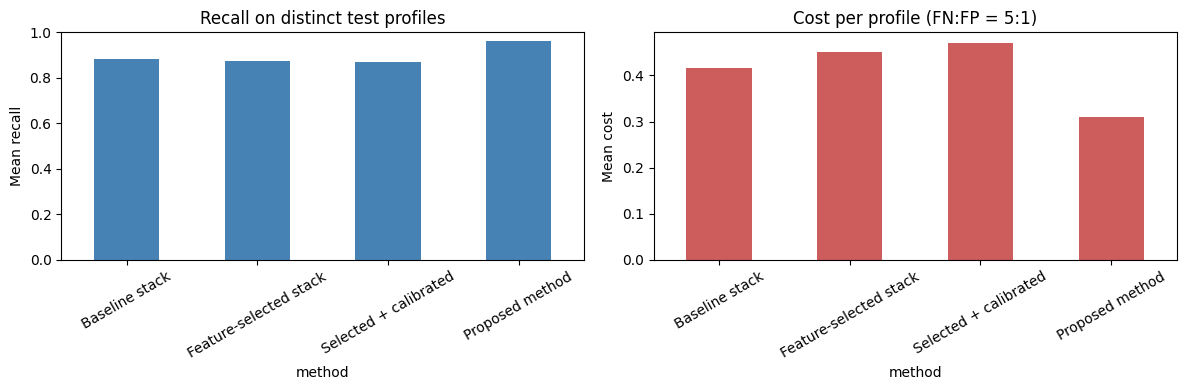

In [34]:
paired = part2.pivot(index = 'split', columns = 'method', values = metric_names_part2)
baseline = paired.xs('Baseline stack', axis = 1, level = 'method')
proposed = paired.xs('Proposed method', axis = 1, level = 'method')
difference = proposed - baseline
print('Proposed minus baseline on each matched test fold:')
display(difference.round(4))
print('Mean paired difference:')
display(difference.mean().rename('Proposed minus baseline').to_frame().round(4))
print('Splits with lower cost:', int((difference.cost_per_record < 0).sum()),
      '/', len(difference))

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
part2_mean['recall'].plot(kind = 'bar', color = 'steelblue', ax = axes[0])
axes[0].set(title = 'Recall on distinct test profiles', ylabel = 'Mean recall', ylim = (0, 1))
part2_mean['cost_per_record'].plot(kind = 'bar', color = 'indianred', ax = axes[1])
axes[1].set(title = 'Cost per profile (FN:FP = 5:1)', ylabel = 'Mean cost')
for ax in axes: ax.tick_params(axis = 'x', rotation = 30)
plt.tight_layout()
plt.show()

### Cost-based Decision Rule Analysis

,baseline_cost,proposed_cost,baseline_recall,proposed_recall,cost_difference
cost_ratio,,,,,
1,0.1655,0.1855,0.8842,0.8688,0.0199
2,0.2284,0.2251,0.8842,0.9206,-0.0033
3,0.2912,0.2515,0.8842,0.9452,-0.0397
4,0.3541,0.2762,0.8842,0.9575,-0.0779
5,0.4169,0.3093,0.8842,0.9605,-0.1076
6,0.4798,0.3393,0.8842,0.9666,-0.1405
7,0.5426,0.3622,0.8842,0.9727,-0.1804
8,0.6054,0.3873,0.8842,0.9788,-0.2181
9,0.6683,0.3890,0.8842,0.9848,-0.2792


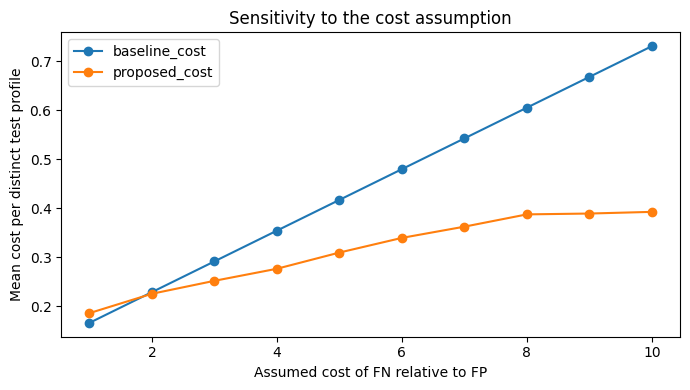

In [35]:
sensitivity_rows = []
for cost_ratio in range(1, 11):
    threshold = 1 / (1 + cost_ratio)
    for record in probability_records:
        baseline_result = evaluate_part2(
            record['actual'], record['baseline_probability'], 0.5, cost_ratio
        )
        proposed_result = evaluate_part2(
            record['actual'], record['calibrated_probability'], threshold, cost_ratio
        )
        sensitivity_rows.append(dict(
            cost_ratio = cost_ratio, split=record['split'],
            baseline_cost = baseline_result['cost_per_record'],
            proposed_cost = proposed_result['cost_per_record'],
            baseline_recall = baseline_result['recall'],
            proposed_recall = proposed_result['recall']
        ))
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_mean = sensitivity.groupby('cost_ratio')[[
    'baseline_cost','proposed_cost','baseline_recall','proposed_recall'
]].mean()
sensitivity_mean['cost_difference'] = (
    sensitivity_mean['proposed_cost'] - sensitivity_mean['baseline_cost']
)
display(sensitivity_mean.round(4))
sensitivity_mean[['baseline_cost','proposed_cost']].plot(marker = 'o', figsize = (7, 4))
plt.xlabel('Assumed cost of FN relative to FP')
plt.ylabel('Mean cost per distinct test profile')
plt.title('Sensitivity to the cost assumption')
plt.tight_layout()
plt.show()

In [36]:
cost_rows = []

for r in [1, 2, 3, 5, 7, 10]:
    threshold = 1 / (1 + r)

    for record in probability_records:
        result = evaluate_part2(
            record["actual"],
            record["calibrated_probability"],
            threshold = threshold,
            cost_ratio = r
        )

        cost_rows.append({
            "split": record["split"],
            "cost_ratio": r,
            "threshold": threshold,
            "recall": result["recall"],
            "specificity": result["specificity"],
            "fp": result["fp"],
            "fn": result["fn"],
            "cost_per_record": result["cost_per_record"]
        })

cost_sensitivity = pd.DataFrame(cost_rows)

display(
    cost_sensitivity
    .groupby("cost_ratio")[
        ["threshold", "recall", "specificity",
         "fp", "fn", "cost_per_record"]
    ]
    .mean()
    .round(4)
)

,threshold,recall,specificity,fp,fn,cost_per_record
cost_ratio,,,,,,
1,0.5000,0.8688,0.7500,6.9,4.3,0.1855
2,0.3333,0.9206,0.6960,8.4,2.6,0.2251
3,0.2500,0.9452,0.6448,9.8,1.8,0.2515
5,0.1667,0.9605,0.5581,12.2,1.3,0.3093
7,0.1250,0.9727,0.4349,15.6,0.9,0.3622
10,0.0909,0.9879,0.2858,19.7,0.4,0.3925
